In [1]:
!pip install langgraph

In [2]:
from langgraph.graph import START,END,StateGraph
from typing import TypedDict
import random

In [3]:
class JourneyState(TypedDict):
  current_location:str

In [4]:
def coimb(state:JourneyState)->JourneyState:
  print("Starting Journey from coimbatore")
  return {"current_location" :"Departed from coimbatore"}

In [5]:
def trichy(state:JourneyState)->JourneyState:
  print("Arrived at trichy")
  return {"current_location" :"Visited trichy"}

In [6]:
def salem(state:JourneyState)->JourneyState:
  print("Arrived at salem")
  return {"current_location" :"Visited salem"}

In [7]:
builder=StateGraph(JourneyState)

In [8]:
builder.add_node("coimbatore",coimb)

In [9]:
builder.add_node("trichy",trichy)

In [10]:
builder.add_node("salem",salem)

In [11]:
builder.add_edge(START,"coimbatore")

In [12]:
def decide_interm_city(state:JourneyState):
  print(f"Deciding route..Last Update:{state['current_location']}")
  if random.random()<0.5:
    print("Route selected: Trichy")
    return "trichy"
  else:
    print("Route selected: Salem")
    return "salem"


In [13]:
builder.add_conditional_edges("coimbatore",decide_interm_city)

In [14]:
builder.add_edge("trichy",END)
builder.add_edge("salem",END)

In [15]:
graph=builder.compile()

In [16]:
graph.invoke({"current_loaction":"coimbatore"})

Starting Journey from coimbatore
Deciding route..Last Update:Departed from coimbatore
Route selected: Salem
Arrived at salem


{'current_location': 'Visited salem'}

In [4]:
!pip install langchain_groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.6 MB/s eta 0:00:00


In [5]:
from langchain_groq import ChatGroq

In [6]:
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage

In [9]:
import os
import getpass

if "GROQ_API_KEY" not in os.environ:
  os.environ["GROQ_API_KEY"]=getpass.getpass("Enter api key")

In [10]:
llm=ChatGroq(model="openai/gpt-oss-120b",
             temperature=0,
             max_tokens=None,
             )

In [29]:
def mul(a:int,b:int)->int:
  """Multiply a and b.

  Args:
    a: first int
    b: second int"""
  return a*b


In [30]:
llm_with_tools=llm.bind_tools([mul])

In [31]:
res=llm_with_tools.invoke([HumanMessage(content=f"What is 1317318317 multiplied with 137811413",name="Shebin")])

In [32]:
res

AIMessage(content='', additional_kwargs={'reasoning_content': "We need to compute product of 1,317,318,317 and 137,811,413. Use multiplication. Let's compute.\n\nWe can use Python mental? Let's do stepwise.\n\nCompute 1,317,318,317 * 137,811,413.\n\nWe can break down: Use big integer multiplication.\n\nLet A = 1,317,318,317.\nB = 137,811,413.\n\nWe can compute using splitting: B = 137,000,000 + 811,413? Actually 137,811,413 = 137 million + 811,413.\n\nCompute A * 137,000,000 = A * 137 * 1,000,000.\n\nFirst compute A * 137.\n\nA * 100 = 131,731,831,700\nA * 30 = 39,519,549,510\nA * 7 = 9,221,228,219\n\nSum: 131,731,831,700 + 39,519,549,510 = 171,251,381,210\nAdd 9,221,228,219 = 180,472,609,429.\n\nSo A*137 = 180,472,609,429.\n\nNow times 1,000,000 => 180,472,609,429,000,000.\n\nNow compute A * 811,413.\n\nBreak 811,413 = 811,000 + 413.\n\nFirst A * 811,000 = A * 811 * 1,000.\n\nCompute A * 811 = A*800 + A*11.\n\nA*800 = A*8*100 = (1,317,318,317*8)=10,538,546,536 then *100 = 1,053,854,65

In [33]:
res.tool_calls

[{'name': 'mul',
  'args': {'a': 1317318317, 'b': 137811413},
  'id': 'fc_e5117faa-c4ae-4192-b234-3d0215dd428d',
  'type': 'tool_call'}]

In [34]:
from langgraph.graph import MessagesState

#WE can directly use the MessagesState itself directly for the state type but if we want to define more parameters in the future means we can use the class


In [35]:
class MessagesState(MessagesState):
  pass


Example

Suppose user says:

Hi

Then state becomes something like:

{
   "messages":[
      HumanMessage(content="Hi")
   ]
}
Then AI replies
Hello! How can I help?

Now state becomes:

{
   "messages":[
      HumanMessage(content="Hi"),

      AIMessage(content="Hello! How can I help?")
   ]
}
Then user asks again
What is 5*6?

Now:

{
   "messages":[
      HumanMessage(content="Hi"),

      AIMessage(content="Hello! How can I help?"),

      HumanMessage(content="What is 5*6?")
   ]
}
So when you do:
state["messages"]

you get ALL previous chat history.

In [36]:
def llm_with_tool_calling(state:MessagesState):
  return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [37]:
builder=StateGraph(MessagesState)

In [38]:
builder.add_node("llm_with_tools",llm_with_tool_calling)

In [39]:
builder.add_edge(START,"llm_with_tools")

In [40]:
builder.add_edge("llm_with_tools",END)

In [41]:
graph=builder.compile()

In [42]:
messages=graph.invoke({"messages":HumanMessage(content="Whats the date today")})

In [43]:
messages

{'messages': [HumanMessage(content='Whats the date today', additional_kwargs={}, response_metadata={}, id='b84e9588-6ace-47f7-bc56-5014a00f7e5e'),
  AIMessage(content='Today’s date is May\u202f25,\u202f2026.', additional_kwargs={'reasoning_content': 'User asks: "Whats the date today". We need to answer with current date. The system says current date: 2026-05-25. So answer: Today is May 25, 2026.'}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 131, 'total_tokens': 197, 'completion_time': 0.138785336, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.006484427, 'prompt_tokens_details': None, 'queue_time': 0.022017962, 'total_time': 0.145269763}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_88d246c915', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5f95-5e03-7230-bbbc-e4e8299691e6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_token

In [44]:
messages=graph.invoke({"messages":HumanMessage(content="8131837138*3178318313")})

In [45]:
messages

{'messages': [HumanMessage(content='8131837138*3178318313', additional_kwargs={}, response_metadata={}, id='5459a93b-09a5-4794-a8bb-45963b86e9bc'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to compute product of two large numbers: 8,131,837,138 * 3,178,318,313.\n\nWe can use multiplication. Let's compute using Python mental? Might be large. Use function mul? It multiplies two ints. Use tool.", 'tool_calls': [{'id': 'fc_9d48f60a-ad23-4c7d-af30-e482043759e5', 'function': {'arguments': '{"a":8131837138,"b":3178318313}', 'name': 'mul'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 136, 'total_tokens': 232, 'completion_time': 0.201697774, 'completion_tokens_details': {'reasoning_tokens': 57}, 'prompt_time': 0.006260408, 'prompt_tokens_details': None, 'queue_time': 0.024257331, 'total_time': 0.207958182}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_f73454f048', 'service_tier': 'on_demand'

**LANGGRAPH ROUTER**



In [46]:
from langgraph.prebuilt import ToolNode,tools_condition

In [47]:
llm2=ChatGroq(model="openai/gpt-oss-120b",
             temperature=0,
             max_tokens=None,
             )

In [48]:
llm2_with_tools = llm2.bind_tools([mul])

In [49]:
def tool_calling_2(state:MessagesState):
  return {"messages":[llm2_with_tools.invoke(state["messages"])]}

In [50]:
builder=StateGraph(MessagesState)

In [51]:
builder.add_node("tool_calling_2",tool_calling_2)


In [52]:
builder.add_node("tools",ToolNode([mul]))

In [53]:
builder.add_edge(START,"tool_calling_2")

In [54]:
builder.add_conditional_edges("tool_calling_2",tools_condition)

In [55]:
builder.add_edge("tools",END)

In [56]:
graph2=builder.compile()

In [57]:
from IPython.display import display, Image

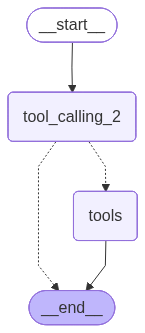

In [58]:
display(Image(graph2.get_graph().draw_mermaid_png()))

In [59]:
messages = graph2.invoke({
    "messages":[
        HumanMessage(
            content="What is 318392323232391 * 3223213313131213 "
        )
    ]
})
for m in messages["messages"]:
    print(type(m))
    print(m)
    print("\n")

<class 'langchain_core.messages.human.HumanMessage'>
content='What is 318392323232391 * 3223213313131213 ' additional_kwargs={} response_metadata={} id='006d06c9-7e14-4d6b-a459-f4758c757db9'


<class 'langchain_core.messages.ai.AIMessage'>
content='' additional_kwargs={'reasoning_content': 'We need to compute multiplication of two large numbers: 318,392,323,232,391 * 3,223,213,313,131,213. That\'s huge (approx 3.18e14 * 3.22e15 = ~1.025e30). We can compute using arbitrary precision. Could do manually? Better to use multiplication via Python mental? Might be error prone. Could use the provided mul function but it expects numbers (JavaScript numbers) which are limited to 2^53-1 (~9e15). Our numbers exceed that, so can\'t use mul. Must compute manually or using big integer arithmetic reasoning. Let\'s try to compute using manual big integer multiplication.\n\nLet A = 318,392,323,232,391\nB = 3,223,213,313,131,213\n\nWe can break down.\n\nI\'ll use long multiplication using splitting into 

**ReAct, Conversation Memory**


In [61]:

def add(a: int, b: int) -> int:
    """
    Adds a and b.

    Args:
        a: first int
        b: second int
    """

    return a + b


def multiply(a: int, b: int) -> int:
    """
    Multiplies a and b.

    Args:
        a: first int
        b: second int
    """

    return a * b


def divide(a: int, b: int) -> float:
    """
    Divide a and b.

    Args:
        a: first int
        b: second int
    """

    return a / b


tools = [add, multiply, divide]


In [62]:
llm3 = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2
)

In [63]:
llm3_with_tools=llm3.bind_tools(tools)

In [64]:
sys_msg = SystemMessage(
    content="""
You are a math assistant.

Use ONLY the provided tools:
- add
- multiply
- divide

Do not use any other tool names.
"""
)

def assistant(state: MessagesState):

    return {
        "messages": [
            llm3_with_tools.invoke(
                [sys_msg] + state["messages"]
            )
        ]
    }


**MEMORY**

In [65]:
from langgraph.checkpoint.memory import MemorySaver

In [66]:
builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)

builder.add_node(
    "tools",
    ToolNode(tools)
)

builder.add_edge(
    START,
    "assistant"
)

builder.add_conditional_edges(
    "assistant",
    tools_condition
)

builder.add_edge(
    "tools",
    "assistant"
)



In [67]:
memory=MemorySaver()
graph4 = builder.compile(checkpointer=memory)
config={"configurable":{"thread_id":"1"}}

In [68]:

message="whats the product of 1318 and 1313"
output=graph4.invoke({"messages":[HumanMessage(content=message)]},config)

In [69]:
output

{'messages': [HumanMessage(content='whats the product of 1318 and 1313', additional_kwargs={}, response_metadata={}, id='24836bc2-22a0-441c-856c-a24cf61bd4d6'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'nmmxhfv04', 'function': {'arguments': '{"a":1318,"b":1313}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 395, 'total_tokens': 416, 'completion_time': 0.071965388, 'completion_tokens_details': None, 'prompt_time': 0.03153464, 'prompt_tokens_details': None, 'queue_time': 0.063193019, 'total_time': 0.103500028}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5f95-cdc5-7c33-b27e-ad85f81e3490-0', tool_calls=[{'name': 'multiply', 'args': {'a': 1318, 'b': 1313}, 'id': 'nmmxhfv04', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'

In [70]:

message="whats my prev msg"
output=graph4.invoke({"messages":[HumanMessage(content=message)]},config)

In [71]:
output

{'messages': [HumanMessage(content='whats the product of 1318 and 1313', additional_kwargs={}, response_metadata={}, id='24836bc2-22a0-441c-856c-a24cf61bd4d6'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'nmmxhfv04', 'function': {'arguments': '{"a":1318,"b":1313}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 395, 'total_tokens': 416, 'completion_time': 0.071965388, 'completion_tokens_details': None, 'prompt_time': 0.03153464, 'prompt_tokens_details': None, 'queue_time': 0.063193019, 'total_time': 0.103500028}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5f95-cdc5-7c33-b27e-ad85f81e3490-0', tool_calls=[{'name': 'multiply', 'args': {'a': 1318, 'b': 1313}, 'id': 'nmmxhfv04', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'